# making more wont stop (Edition 3)

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8] 

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
block_size = 3

def build_database(words):
    X, Y = [], []

    for w in words:
        context = [0] *block_size

        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_database(words[:n1])
Xdev, Yval = build_database(words[n1:n2])
Xte, Yte = build_database(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [18]:
n_embd = 10
n_hidden = 200

g = torch.Generator()
C = torch.randn((vocab_size, n_embd),             generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / (n_embd * block_size)**0.5
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn((vocab_size),                    generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

11897


tensor(0.0006) tensor(0.9868)
tensor(0.0020) tensor(1.0134)


(array([4.38135051e-05, 8.76270103e-05, 0.00000000e+00, 1.53347268e-04,
        1.75254021e-04, 3.72414794e-04, 7.22922835e-04, 1.27059165e-03,
        2.60690356e-03, 4.14037623e-03, 6.04626371e-03, 1.10410033e-02,
        1.74377750e-02, 2.63319166e-02, 4.20828717e-02, 6.11198397e-02,
        8.93576437e-02, 1.29403187e-01, 1.75254021e-01, 2.31554375e-01,
        2.95412558e-01, 3.47923044e-01, 3.99776328e-01, 4.23128926e-01,
        4.15965418e-01, 3.83718678e-01, 3.32960732e-01, 2.68357719e-01,
        2.14050879e-01, 1.56195146e-01, 1.14638036e-01, 7.81194796e-02,
        5.37591708e-02, 3.62775822e-02, 2.53461127e-02, 1.43708297e-02,
        8.95986180e-03, 4.95092608e-03, 3.54889392e-03, 2.05923474e-03,
        1.00771062e-03, 5.03855309e-04, 5.91482319e-04, 2.40974278e-04,
        1.31440515e-04, 4.38135051e-05, 2.19067526e-05, 4.38135051e-05,
        2.19067526e-05, 2.19067526e-05]),
 array([-5.43677521, -5.20853508, -4.98029495, -4.75205482, -4.5238147 ,
        -4.29557457, 

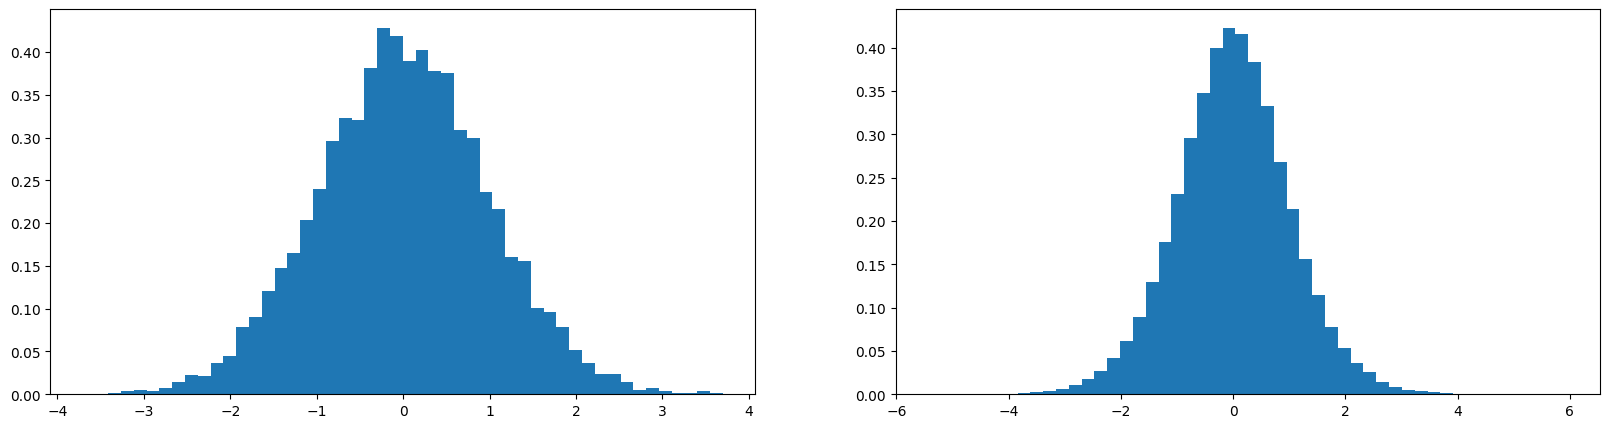

In [19]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())

plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True)

In [20]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad
    
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item(): .4f}')
    lossi.append(loss.log10().item())
    # break

      0/ 200000:  3.3145
  10000/ 200000:  2.3344
  20000/ 200000:  2.7147
  30000/ 200000:  1.9966
  40000/ 200000:  2.2091
  50000/ 200000:  2.1893
  60000/ 200000:  2.2555
  70000/ 200000:  1.5310
  80000/ 200000:  1.9159
  90000/ 200000:  2.0257
 100000/ 200000:  2.2096
 110000/ 200000:  2.2008
 120000/ 200000:  2.1800
 130000/ 200000:  1.6528
 140000/ 200000:  1.9182
 150000/ 200000:  2.0937
 160000/ 200000:  2.2705
 170000/ 200000:  2.0148
 180000/ 200000:  1.7149
 190000/ 200000:  1.9794


(array([1173.,  286.,  173.,  139.,  121.,   83.,   89.,   75.,   72.,
          70.,   66.,   74.,   76.,   46.,   62.,   44.,   59.,   47.,
          48.,   65.,   42.,   48.,   45.,   53.,   39.,   57.,   50.,
          52.,   40.,   52.,   45.,   64.,   52.,   48.,   43.,   66.,
          64.,   52.,   71.,   64.,   67.,   69.,   75.,   92.,   87.,
         120.,  143.,  184.,  307., 1341.]),
 array([-1.00000000e+00, -9.60000001e-01, -9.20000002e-01, -8.80000004e-01,
        -8.40000005e-01, -8.00000006e-01, -7.60000007e-01, -7.20000008e-01,
        -6.80000010e-01, -6.40000011e-01, -6.00000012e-01, -5.60000013e-01,
        -5.20000014e-01, -4.80000015e-01, -4.40000017e-01, -4.00000018e-01,
        -3.60000019e-01, -3.20000020e-01, -2.80000021e-01, -2.40000023e-01,
        -2.00000024e-01, -1.60000025e-01, -1.20000026e-01, -8.00000274e-02,
        -4.00000286e-02, -2.98023224e-08,  3.99999690e-02,  7.99999678e-02,
         1.19999967e-01,  1.59999965e-01,  1.99999964e-01,  2.399999

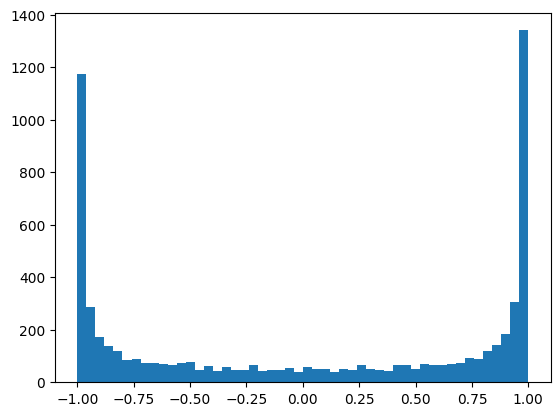

In [21]:
plt.hist(h.view(-1).tolist(), 50)

(array([  1.,   0.,   0.,   0.,   0.,   5.,   2.,   6.,   4.,  16.,  17.,
         24.,  21.,  43.,  55.,  68.,  89., 105., 135., 171., 208., 270.,
        327., 358., 366., 453., 471., 455., 413., 375., 338., 312., 270.,
        217., 165., 161., 124.,  78.,  73.,  61.,  48.,  28.,  20.,  19.,
         13.,   5.,   6.,   1.,   0.,   3.]),
 array([-10.34842682,  -9.96176626,  -9.57510571,  -9.18844515,
         -8.80178459,  -8.41512403,  -8.02846348,  -7.64180292,
         -7.25514236,  -6.86848181,  -6.48182125,  -6.09516069,
         -5.70850014,  -5.32183958,  -4.93517902,  -4.54851847,
         -4.16185791,  -3.77519735,  -3.3885368 ,  -3.00187624,
         -2.61521568,  -2.22855513,  -1.84189457,  -1.45523401,
         -1.06857346,  -0.6819129 ,  -0.29525234,   0.09140821,
          0.47806877,   0.86472933,   1.25138988,   1.63805044,
          2.024711  ,   2.41137156,   2.79803211,   3.18469267,
          3.57135323,   3.95801378,   4.34467434,   4.7313349 ,
          5.117995

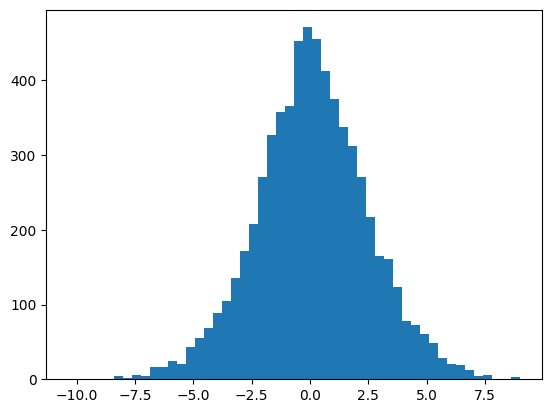

In [22]:
plt.hist(hpreact.view(-1).tolist(), 50)

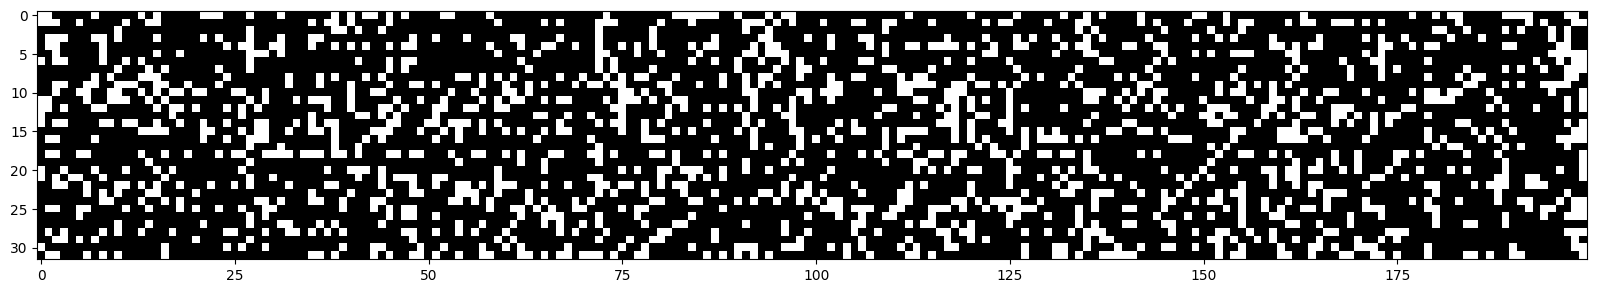

In [23]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

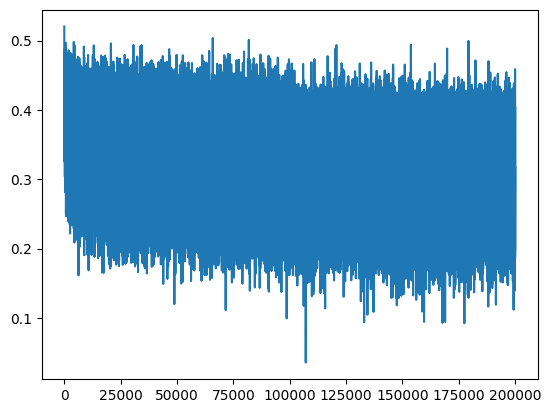

In [24]:
plt.plot(lossi)

In [25]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Yval),
        'test': (Xte, Yte),
    }[split]

    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')
split_loss('test')

train 2.043320417404175
val 2.1068789958953857
test 2.109286308288574


In [26]:
g = torch.Generator()

for _ in range(20):

    out = []
    context = [0] * block_size

    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out))

kodolaiyah.
via.
adricka.
jaqua.
helindi.
beon.
jemira.
arversyanna.
mazeton.
zelynn.
kas.
zicus.
zadrea.
couwa.
vien.
jwlolayzah.
marla.
oakl.
davi.
halayden.
